In [ ]:

import os

# 1. Set your Kaggle Username and Token directly
os.environ['KAGGLE_USERNAME'] = 'valentinosalvatore'
os.environ['KAGGLE_KEY'] = 'KGAT_f73428722058c4401d3e3cd59281c41e'

# 2. Download the Chest X-Ray dataset directly from Kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# 3. Unzip the downloaded dataset
import zipfile
with zipfile.ZipFile("chest-xray-pneumonia.zip", "r") as zip_ref:
    zip_ref.extractall("chest_xray_data")

print("⚡ Dataset successfully downloaded and unzipped!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:22<00:00, 109MB/s]

⚡ Dataset successfully downloaded and unzipped!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = 'chest_xray_data/chest_xray/train'
test_dir = 'chest_xray_data/chest_xray/test'

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading training images...")
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')

print("\nLoading testing images...")
test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')

Loading training images...
Found 5216 images belonging to 2 classes.

Loading testing images...
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import layers, models

# Initialize a sequential neural network model
model = models.Sequential([
    # Layer 1: The AI scans for basic shapes, edges, and lines in the X-rays
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    # Layer 2: The AI combines edges into more complex patterns (like lung curves)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Layer 3: The AI focuses on fine details and dark fluid build-ups
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Flatten the 2D images into a 1D list of data points
    layers.Flatten(),

    # Dense Layer: Connect everything together to make a final decision
    layers.Dense(512, activation='relu'),

    # Output Layer: 1 node outputs a probability between 0 (Normal) and 1 (Pneumonia)
    layers.Dense(1, activation='sigmoid')
])

# Compile the model with settings for a binary (yes/no) decision
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print a visual blueprint of the AI we just built
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model for 5 full passes (epochs) through the dataset
history = model.fit(
        train_generator,
        epochs=5,
        validation_data=test_generator)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 61s 337ms/step - accuracy: 0.9045 - loss: 0.2731 - val_accuracy: 0.7644 - val_loss: 0.7785
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 313ms/step - accuracy: 0.9617 - loss: 0.1035 - val_accuracy: 0.7484 - val_loss: 1.0858
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 310ms/step - accuracy: 0.9735 - loss: 0.0718 - val_accuracy: 0.7340 - val_loss: 1.2994
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 309ms/step - accuracy: 0.9778 - loss: 0.0617 - val_accuracy: 0.7580 - val_loss: 1.0466
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 310ms/step - accuracy: 0.9770 - loss: 0.0595 - val_accuracy: 0.7821 - val_loss: 1.0186


In [ ]:
# Save the trained model to a file
model.save('pneumonia_detection_model.h5')
print("💾 Model successfully saved as pneumonia_detection_model.h5!")


💾 Model successfully saved as pneumonia_detection_model.h5!


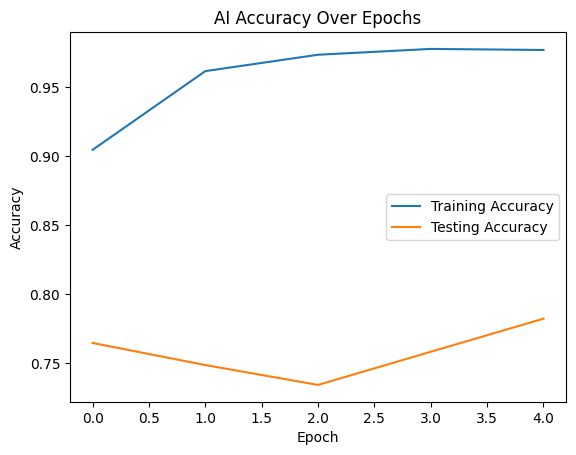

In [ ]:
import matplotlib.pyplot as plt

# Plot Training vs Testing Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')
plt.title('AI Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import os

# 1. Grab the very first image from the hidden test folder for Pneumonia
test_folder = 'chest_xray_data/chest_xray/test/PNEUMONIA'
all_images = os.listdir(test_folder)
sample_image_path = os.path.join(test_folder, all_images[0])

# 2. Load and preprocess the image so the AI can read it
img = image.load_img(sample_image_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalize pixels

# 3. Make the prediction!
prediction = model.predict(img_array)

print("\n--- AI DIAGNOSIS ---")
if prediction[0][0] > 0.5:
    print(f"Result: PNEUMONIA DETECTED (Confidence: {prediction[0][0]*100:.2f}%)")
else:
    print(f"Result: LUNGS ARE NORMAL (Confidence: {(1 - prediction[0][0])*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step

--- AI DIAGNOSIS ---
Result: PNEUMONIA DETECTED (Confidence: 100.00%)


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files

# 1. Open a prompt to upload an image from your Mac
print("Click the button below to upload an X-ray image (.jpg or .jpeg):\n")
uploaded = files.upload()

# 2. Get the file path of whatever image you just uploaded
for file_name in uploaded.keys():
    print(file_name)

    # 3. Load and preprocess your image
    img = image.load_img(file_name, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize pixels

    # 4. Run it through your trained AI brain
    prediction = model.predict(img_array)

    # 5. Output the diagnosis
    print("\n==============================")
    print("      AI DIAGNOSIS VERDICT      ")
    print("==============================")
    if prediction[0][0] > 0.5:
        print(f"Result: PNEUMONIA DETECTED")
        print(f"Confidence: {prediction[0][0]*100:.2f}%")
    else:
        print(f"Result: LUNGS ARE NORMAL")
        print(f"Confidence: {(1 - prediction[0][0])*100:.2f}%")
    print("==============================")


Click the button below to upload an X-ray image (.jpg or .jpeg):



Saving pneumonia sample.png to pneumonia sample.png
pneumonia sample.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

      AI DIAGNOSIS VERDICT      
Result: PNEUMONIA DETECTED
Confidence: 100.00%
